In [20]:
import polars as pl
import pandas as pd
import numpy as np
import joblib
from plotnine import *
# scikit learn imports
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [21]:
path = '../data/ca-dealers-used-cleaned.csv'

In [22]:
def read_csv(file_path):
    return pl.read_csv(file_path)

In [23]:
data = read_csv(path)

In [24]:
data.head()

price,miles,year,make,model,body_type,vehicle_type,drivetrain,transmission,fuel_type,engine_size,engine_block,state,make_model,group_col
i64,i64,i64,str,str,str,str,str,str,str,f64,str,str,str,str
179999,9966,2017,"""Acura""","""NSX""","""Coupe""","""Car""","""4WD""","""Automatic""","""hybrid""",3.5,"""V""","""NB""","""Acura_NSX""","""other"""
179995,5988,2017,"""Acura""","""NSX""","""Coupe""","""Car""","""4WD""","""Automatic""","""hybrid""",3.5,"""V""","""QC""","""Acura_NSX""","""other"""
168528,24242,2017,"""Acura""","""NSX""","""Coupe""","""Car""","""4WD""","""Automatic""","""hybrid""",3.5,"""V""","""BC""","""Acura_NSX""","""other"""
220000,6637,2020,"""Acura""","""NSX""","""Coupe""","""Car""","""4WD""","""Automatic""","""hybrid""",3.5,"""V""","""ON""","""Acura_NSX""","""other"""
220000,6637,2020,"""Acura""","""NSX""","""Coupe""","""Car""","""4WD""","""Automatic""","""hybrid""",3.5,"""V""","""ON""","""Acura_NSX""","""other"""


In [25]:
# subject matter expert has identified these columns as not useful for modeling, so we will drop them
cols_to_drop = [
    'body_type',
    'vehicle_type',
    'drivetrain',
    'transmission',
    'fuel_type',
    'engine_block',
    'make_model', # this is a combination of make and model
]

selected_data = data.select(pl.exclude(cols_to_drop))

In [26]:
# for illustration, I only select honda and toyota, but in practice, I would select all the makes that have a significant number of records
subset_selected_data = selected_data.filter(pl.col('make').is_in(['Honda', 'Toyota']))

In [27]:
subset_selected_data.head()

price,miles,year,make,model,engine_size,state,group_col
i64,i64,i64,str,str,f64,str,str
4980,86132,2001,"""Toyota""","""Prius""",1.5,"""BC""","""Toyota_Prius"""
4488,310119,2006,"""Toyota""","""Highlander""",3.3,"""ON""","""Toyota_Highlander"""
7650,135000,2006,"""Toyota""","""Highlander""",3.3,"""ON""","""Toyota_Highlander"""
8900,130160,2010,"""Honda""","""Civic""",1.8,"""BC""","""Honda_Civic"""
12995,81000,2015,"""Honda""","""Civic""",1.8,"""ON""","""Honda_Civic"""


In [28]:
# group call will be used for stratified groupkfold, so we can check the distribution of the group call to make sure it's not too imbalanced
subset_selected_data['group_col'].value_counts().sort('count', descending=True).head(5)

group_col,count
str,u32
"""Honda_Civic""",5961
"""Honda_CR-V""",5376
"""Toyota_Corolla""",5003
"""Toyota_RAV4""",4964
"""Toyota_Camry""",2292


In [29]:
groups = subset_selected_data['group_col'].to_numpy()

X = subset_selected_data.drop(['group_col', 'price'])
y = subset_selected_data['price'].to_numpy()

# group k fold

In [30]:
from sklearn.model_selection import GroupKFold

gkf = GroupKFold(n_splits=5)

for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups=groups)):
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]
    print(f"Fold {fold}: val groups = {np.unique(groups[val_idx])}")

Fold 0: val groups = ['Honda_Civic' 'Honda_Fit' 'Honda_Odyssey' 'Toyota_Prius' 'Toyota_Prius-c'
 'Toyota_Rav4']
Fold 1: val groups = ['Honda_CR-V' 'Honda_HR-V' 'Honda_Ridgeline' 'Toyota_Corolla-iM'
 'Toyota_Prius-Prime' 'Toyota_Yaris']
Fold 2: val groups = ['Honda_Civic-Hatchback' 'Toyota_4Runner' 'Toyota_Avalon' 'Toyota_Corolla'
 'Toyota_FJ-Cruiser' 'Toyota_Prius-Plug-In' 'Toyota_Sienna' 'Toyota_Venza']
Fold 3: val groups = ['Honda_Pilot' 'Toyota_86' 'Toyota_Corolla-Hatchback' 'Toyota_Matrix'
 'Toyota_Prius-v' 'Toyota_RAV4' 'Toyota_Sequoia' 'Toyota_Tundra']
Fold 4: val groups = ['Honda_Accord' 'Honda_Clarity' 'Honda_Passport' 'Toyota_C-HR'
 'Toyota_Camry' 'Toyota_Highlander' 'Toyota_Tacoma' 'other']


In [31]:
X_train

miles,year,make,model,engine_size,state
i64,i64,str,str,f64,str
86132,2001,"""Toyota""","""Prius""",1.5,"""BC"""
130160,2010,"""Honda""","""Civic""",1.8,"""BC"""
81000,2015,"""Honda""","""Civic""",1.8,"""ON"""
70039,2013,"""Honda""","""Civic""",1.8,"""QC"""
25000,2015,"""Honda""","""Civic""",1.8,"""BC"""
…,…,…,…,…,…
56393,2018,"""Toyota""","""RAV4""",2.5,"""MB"""
100785,2018,"""Toyota""","""RAV4""",2.5,"""BC"""
100850,2018,"""Toyota""","""RAV4""",2.5,"""BC"""


In [32]:
from sklearn.ensemble import GradientBoostingRegressor
cat_index = ['make', 'model', 'state']

cat_features_transformer = Pipeline(
    steps=[
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', cat_features_transformer, cat_index)
    ],
    remainder='passthrough'
)

model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('regressor', GradientBoostingRegressor(random_state=42))
    ]
)

In [33]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers conta

In [34]:
model.score(X_val, y_val)

0.7771261601113714

In [35]:
# ─── CV metrics collection ────────────────────────────────────────────────────
# Run all 5 GroupKFold folds, fit the pipeline on each train split,
# and collect R², RMSE, MAE for every fold.
# We also keep the last fold's predictions for the diagnostic plots below.
# ─────────────────────────────────────────────────────────────────────────────

cv_records = []
last_fold_preds = {}

for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups=groups)):
    # Polars supports row-index slicing; convert to pandas for sklearn
    X_train_f = X[train_idx].to_pandas()
    X_val_f   = X[val_idx].to_pandas()
    y_train_f = y[train_idx]
    y_val_f   = y[val_idx]

    model.fit(X_train_f, y_train_f)
    y_pred = model.predict(X_val_f)

    r2   = r2_score(y_val_f, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val_f, y_pred))
    mae  = mean_absolute_error(y_val_f, y_pred)

    val_groups = ', '.join(np.unique(groups[val_idx]))
    cv_records.append({
        'fold':       fold,
        'val_groups': val_groups,
        'r2':         round(r2,   4),
        'rmse':       round(rmse, 2),
        'mae':        round(mae,  2),
    })
    print(f"Fold {fold} | {val_groups:<35} | R²={r2:.3f} | RMSE=${rmse:>9,.0f} | MAE=${mae:>9,.0f}")

    # Retain last fold for plotting
    last_fold_preds = {'y_val': y_val_f, 'y_pred': y_pred, 'fold': fold}

cv_metrics = pl.DataFrame(cv_records)


Fold 0 | Honda_Civic, Honda_Fit, Honda_Odyssey, Toyota_Prius, Toyota_Prius-c, Toyota_Rav4 | R²=0.540 | RMSE=$    4,232 | MAE=$    3,608
Fold 1 | Honda_CR-V, Honda_HR-V, Honda_Ridgeline, Toyota_Corolla-iM, Toyota_Prius-Prime, Toyota_Yaris | R²=0.500 | RMSE=$    5,737 | MAE=$    4,798
Fold 2 | Honda_Civic-Hatchback, Toyota_4Runner, Toyota_Avalon, Toyota_Corolla, Toyota_FJ-Cruiser, Toyota_Prius-Plug-In, Toyota_Sienna, Toyota_Venza | R²=0.696 | RMSE=$    5,576 | MAE=$    4,462
Fold 3 | Honda_Pilot, Toyota_86, Toyota_Corolla-Hatchback, Toyota_Matrix, Toyota_Prius-v, Toyota_RAV4, Toyota_Sequoia, Toyota_Tundra | R²=0.671 | RMSE=$    5,746 | MAE=$    4,677
Fold 4 | Honda_Accord, Honda_Clarity, Honda_Passport, Toyota_C-HR, Toyota_Camry, Toyota_Highlander, Toyota_Tacoma, other | R²=0.777 | RMSE=$    5,542 | MAE=$    4,259


In [36]:
# ─── CV metrics summary ───────────────────────────────────────────────────────
# Aggregate R², RMSE, MAE across all folds (mean ± std).
# High std → model performance varies a lot between folds (unstable).
# ─────────────────────────────────────────────────────────────────────────────

print("Cross-Validation Summary (5-fold GroupKFold by make+model)")
print("=" * 58)
print(f"{'Metric':<8}  {'Mean':>12}  {'Std':>10}  {'Min':>12}  {'Max':>12}")
print("-" * 58)

for metric, fmt in [('r2', '.4f'), ('rmse', ',.0f'), ('mae', ',.0f')]:
    vals = cv_metrics[metric].to_numpy()
    prefix = '$' if metric != 'r2' else ''
    print(
        f"{metric.upper():<8}  "
        f"{prefix}{vals.mean():{fmt}}{'':<{5 - len(prefix)}}  "
        f"{prefix}{vals.std():{fmt}}{'':<{5 - len(prefix)}}  "
        f"{prefix}{vals.min():{fmt}}{'':<{5 - len(prefix)}}  "
        f"{prefix}{vals.max():{fmt}}"
    )

print()
print(cv_metrics)


Cross-Validation Summary (5-fold GroupKFold by make+model)
Metric            Mean         Std           Min           Max
----------------------------------------------------------
R2        0.6368       0.1024       0.5001       0.7771
RMSE      $5,367      $573      $4,232      $5,746
MAE       $4,361      $419      $3,608      $4,798

shape: (5, 5)
┌──────┬─────────────────────────────────┬────────┬─────────┬─────────┐
│ fold ┆ val_groups                      ┆ r2     ┆ rmse    ┆ mae     │
│ ---  ┆ ---                             ┆ ---    ┆ ---     ┆ ---     │
│ i64  ┆ str                             ┆ f64    ┆ f64     ┆ f64     │
╞══════╪═════════════════════════════════╪════════╪═════════╪═════════╡
│ 0    ┆ Honda_Civic, Honda_Fit, Honda_… ┆ 0.5398 ┆ 4232.12 ┆ 3608.42 │
│ 1    ┆ Honda_CR-V, Honda_HR-V, Honda_… ┆ 0.5001 ┆ 5737.41 ┆ 4798.31 │
│ 2    ┆ Honda_Civic-Hatchback, Toyota_… ┆ 0.6957 ┆ 5575.91 ┆ 4462.29 │
│ 3    ┆ Honda_Pilot, Toyota_86, Toyota… ┆ 0.6711 ┆ 5745.63 ┆ 4676.58 

In [37]:
# ─── GridSearchCV hyperparameter tuning ──────────────────────────────────────
# We tune 4 GradientBoostingRegressor hyperparameters:
#   n_estimators  : number of trees — more = slower but potentially better
#   max_depth     : depth of each tree — deeper = more expressive but overfits
#   learning_rate : shrinks each tree's contribution — lower = needs more trees
#   subsample     : fraction of rows sampled per tree — < 1.0 adds regularisation
#
# Grid: 2×2×2×2 = 16 combinations × 5 folds = 80 fits total.
# scoring='neg_root_mean_squared_error' keeps units in dollars (interpretable).
# GroupKFold is passed as cv so the same leakage-free splits are used.
# ─────────────────────────────────────────────────────────────────────────────

param_grid = {
    'regressor__n_estimators':  [100, 200],
    'regressor__max_depth':     [3, 5],
    'regressor__learning_rate': [0.05, 0.1],
    'regressor__subsample':     [0.8, 1.0],
}

# Convert X to pandas once — GridSearchCV passes subsets to sklearn internally
X_pd = X.to_pandas()

grid_search = GridSearchCV(
    model,
    param_grid,
    cv=GroupKFold(n_splits=5),
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1,
    refit=True,   # refit best estimator on full X_pd after search
)

grid_search.fit(X_pd, y, groups=groups)

print(f"\nBest hyperparameters : {grid_search.best_params_}")
print(f"Best CV RMSE         : ${-grid_search.best_score_:,.0f}")


Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best hyperparameters : {'regressor__learning_rate': 0.1, 'regressor__max_depth': 3, 'regressor__n_estimators': 200, 'regressor__subsample': 1.0}
Best CV RMSE         : $5,344


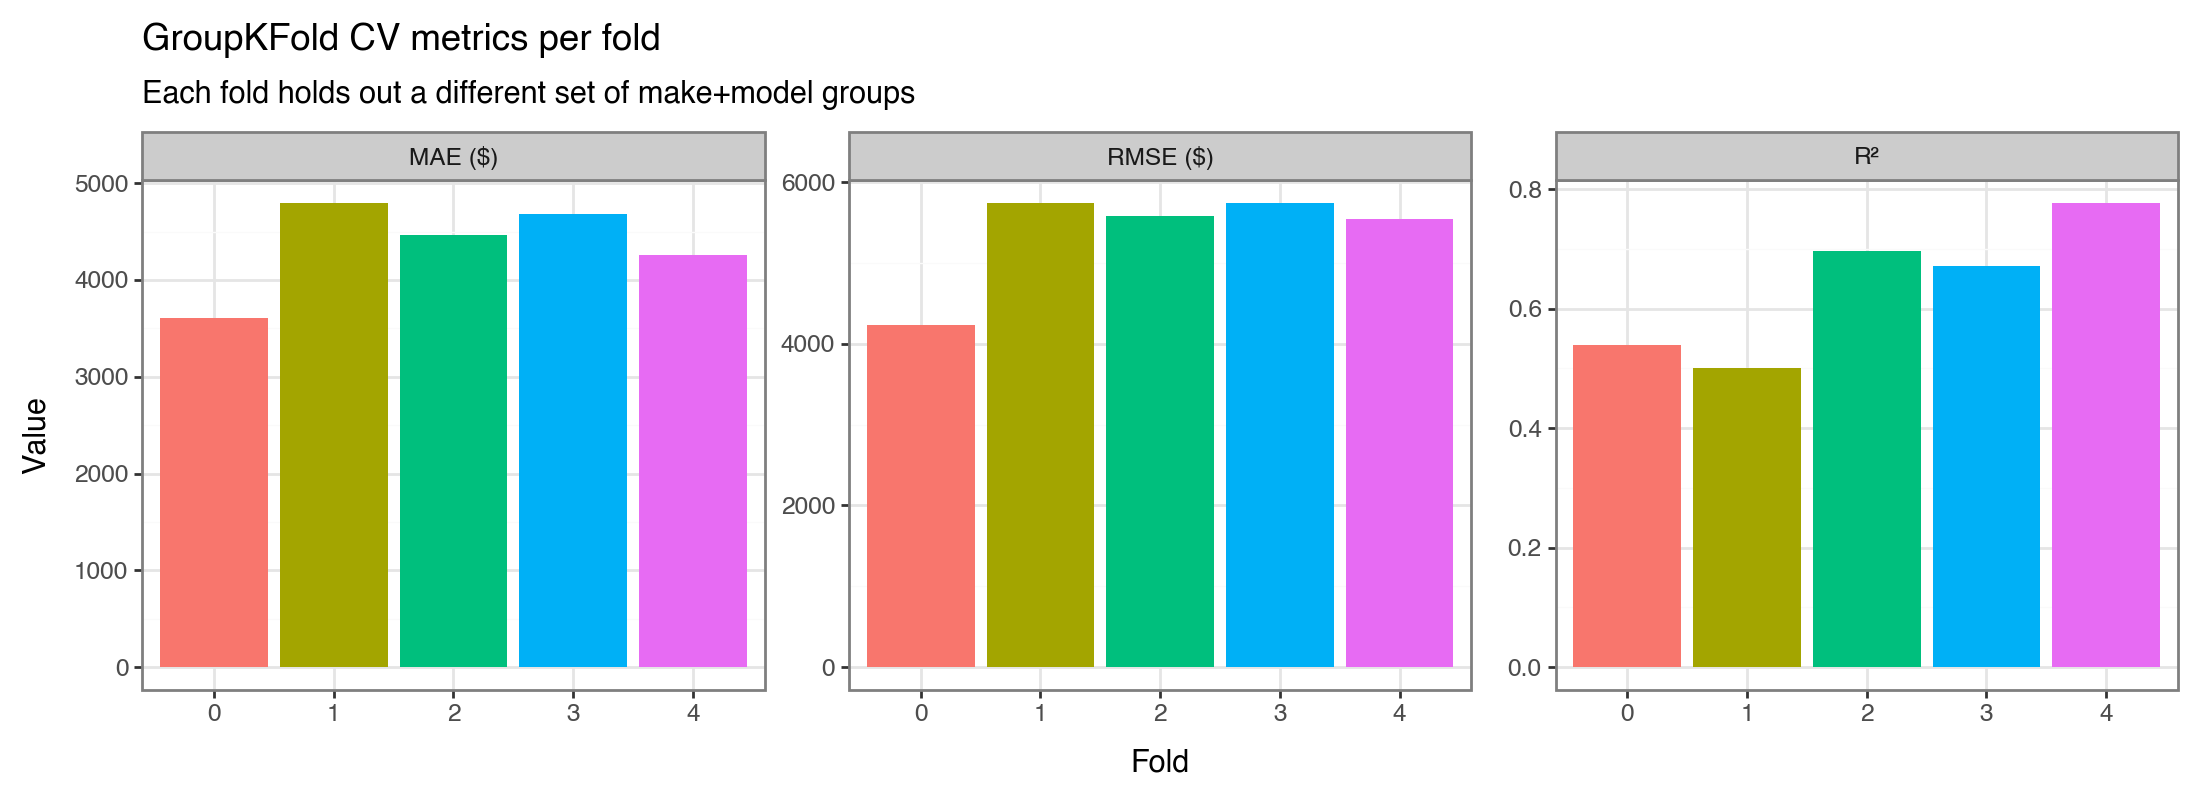

In [38]:
# ─── Plot 1: CV metrics per fold ─────────────────────────────────────────────
# Shows R², RMSE, MAE for each fold side-by-side.
# Stable bars across folds = model is consistent; large variation = unstable.
# ─────────────────────────────────────────────────────────────────────────────

cv_long = (
    cv_metrics
    .to_pandas()
    .melt(
        id_vars=['fold', 'val_groups'],
        value_vars=['r2', 'rmse', 'mae'],
        var_name='metric',
        value_name='value',
    )
)
cv_long['fold'] = cv_long['fold'].astype(str)

# Human-readable metric labels
metric_labels = {'r2': 'R²', 'rmse': 'RMSE ($)', 'mae': 'MAE ($)'}
cv_long['metric_label'] = cv_long['metric'].map(metric_labels)

(
    ggplot(cv_long, aes(x='fold', y='value', fill='fold'))
    + geom_col(show_legend=False)
    + facet_wrap('~metric_label', scales='free_y', ncol=3)
    + labs(
        title='GroupKFold CV metrics per fold',
        subtitle='Each fold holds out a different set of make+model groups',
        x='Fold', y='Value',
    )
    + theme_bw()
    + theme(figure_size=(11, 4))
)


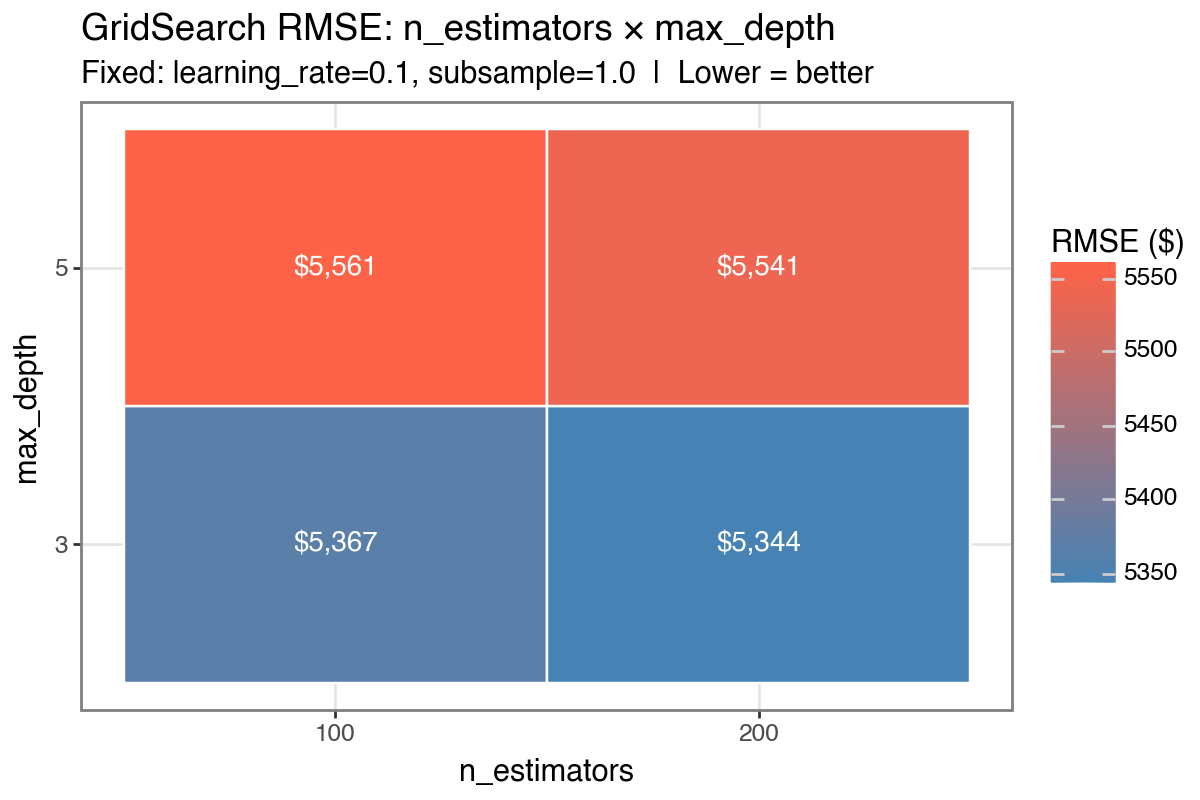

In [39]:
# ─── Plot 2: GridSearch heatmap (n_estimators × max_depth) ───────────────────
# Shows mean CV RMSE for every n_estimators / max_depth combination,
# fixed at the best learning_rate and subsample found by GridSearchCV.
# Blue = lower RMSE (better). Helps explain the best parameter choice.
# ─────────────────────────────────────────────────────────────────────────────

best_lr  = grid_search.best_params_['regressor__learning_rate']
best_sub = grid_search.best_params_['regressor__subsample']

gs_df = pd.DataFrame(grid_search.cv_results_)
heatmap_df = gs_df[
    (gs_df['param_regressor__learning_rate'] == best_lr) &
    (gs_df['param_regressor__subsample']     == best_sub)
].copy()

heatmap_df['rmse']         = (-heatmap_df['mean_test_score']).round(0).astype(int)
heatmap_df['rmse_label']   = heatmap_df['rmse'].apply(lambda v: f'${v:,}')
heatmap_df['n_estimators'] = heatmap_df['param_regressor__n_estimators'].astype(str)
heatmap_df['max_depth']    = heatmap_df['param_regressor__max_depth'].astype(str)

(
    ggplot(heatmap_df, aes(x='n_estimators', y='max_depth', fill='rmse'))
    + geom_tile(color='white', size=0.5)
    + geom_text(aes(label='rmse_label'), size=10, color='white')
    + scale_fill_gradient(low='steelblue', high='tomato', name='RMSE ($)')
    + labs(
        title=f'GridSearch RMSE: n_estimators × max_depth',
        subtitle=f'Fixed: learning_rate={best_lr}, subsample={best_sub}  |  Lower = better',
        x='n_estimators', y='max_depth',
    )
    + theme_bw()
    + theme(figure_size=(6, 4))
)


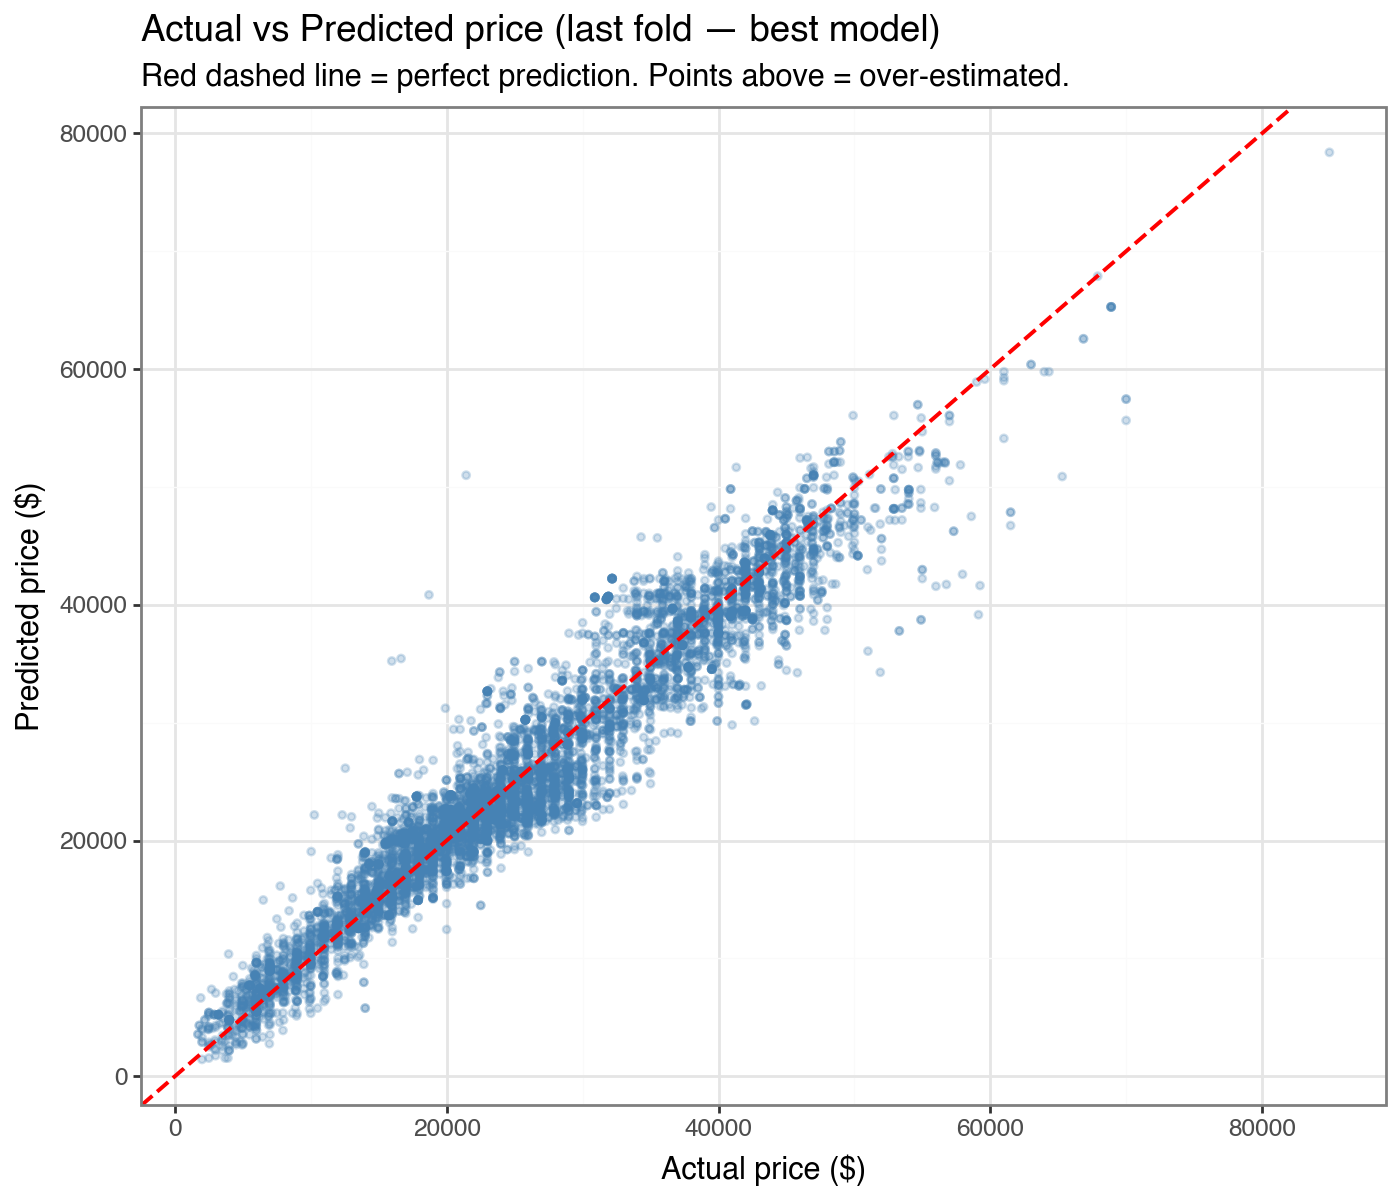

In [40]:
# ─── Plot 3: Actual vs Predicted (last fold, best estimator) ─────────────────
# Predict on the last fold's validation set using the best model from GridSearch.
# Points should cluster tightly around the diagonal (45° red line = perfect).
# Systematic bias shows up as a consistent shift above/below the line.
# ─────────────────────────────────────────────────────────────────────────────

# Re-predict the last fold using the tuned best estimator
_, last_val_idx = list(gkf.split(X, y, groups=groups))[-1]
X_last_val = X[last_val_idx].to_pandas()
y_last_val = y[last_val_idx]
y_last_pred = grid_search.best_estimator_.predict(X_last_val)

scatter_df = pd.DataFrame({
    'actual':    y_last_val,
    'predicted': y_last_pred,
})

(
    ggplot(scatter_df, aes(x='actual', y='predicted'))
    + geom_point(alpha=0.25, size=1, color='steelblue')
    + geom_abline(slope=1, intercept=0, color='red', linetype='dashed', size=0.8)
    + labs(
        title='Actual vs Predicted price (last fold — best model)',
        subtitle='Red dashed line = perfect prediction. Points above = over-estimated.',
        x='Actual price ($)', y='Predicted price ($)',
    )
    + theme_bw()
    + theme(figure_size=(7, 6))
)


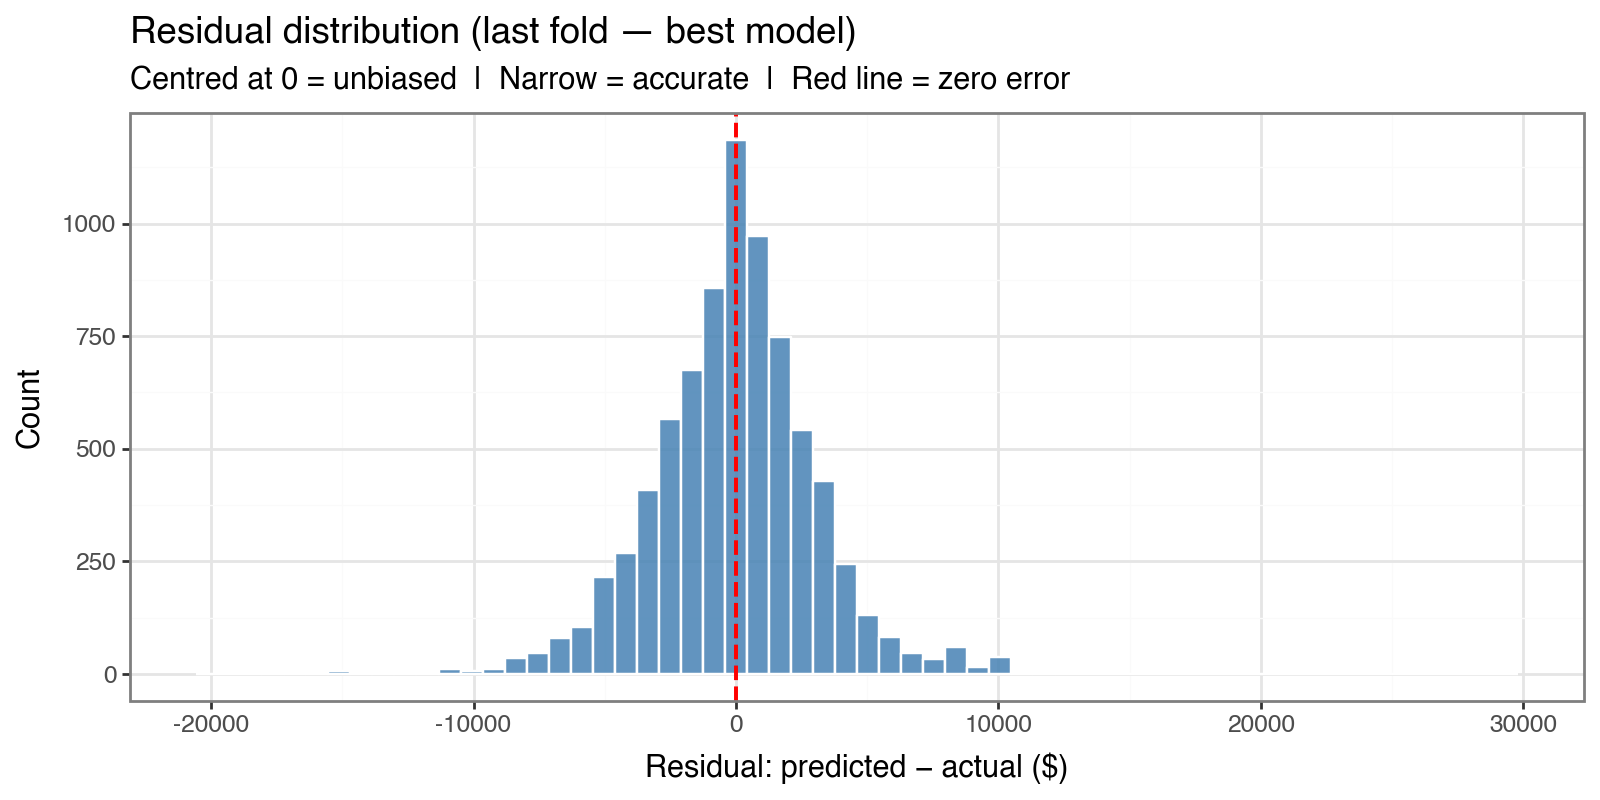

In [41]:
# ─── Plot 4: Residuals distribution ──────────────────────────────────────────
# Residual = predicted − actual.
# A well-behaved model gives residuals centred near 0 (unbiased) and roughly
# bell-shaped (no systematic patterns).
# A heavy right tail = model consistently under-predicts expensive cars.
# ─────────────────────────────────────────────────────────────────────────────

scatter_df['residual'] = scatter_df['predicted'] - scatter_df['actual']

(
    ggplot(scatter_df, aes(x='residual'))
    + geom_histogram(bins=60, fill='steelblue', color='white', alpha=0.85)
    + geom_vline(xintercept=0, color='red', linetype='dashed', size=0.8)
    + labs(
        title='Residual distribution (last fold — best model)',
        subtitle='Centred at 0 = unbiased  |  Narrow = accurate  |  Red line = zero error',
        x='Residual: predicted − actual ($)', y='Count',
    )
    + theme_bw()
    + theme(figure_size=(8, 4))
)


In [42]:
# ─── Refit on all data & save ─────────────────────────────────────────────────
# GridSearchCV with refit=True already refits the best estimator on the full
# X_pd / y passed to .fit(). We just need to dump it.
#
# The saved .joblib includes the full sklearn Pipeline:
#   OneHotEncoder (make, model, state) → GradientBoostingRegressor
# so any downstream code only needs to call .predict(X_pandas).
# ─────────────────────────────────────────────────────────────────────────────

save_path = '../../model.joblib'
best_model = grid_search.best_estimator_
joblib.dump(best_model, save_path)

print(f"Model saved  : {save_path}")
print(f"Best params  : {grid_search.best_params_}")
print(f"Best CV RMSE : ${-grid_search.best_score_:,.0f}")
print()

# Quick sanity-check: reload and predict one row
loaded_model = joblib.load(save_path)
sample_pred = loaded_model.predict(X_pd.head(1))
print(f"Sanity check — predicted price for first row: ${sample_pred[0]:,.0f}")
print(f"Actual price for first row                  : ${y[0]:,.0f}")


Model saved  : ../../model.joblib
Best params  : {'regressor__learning_rate': 0.1, 'regressor__max_depth': 3, 'regressor__n_estimators': 200, 'regressor__subsample': 1.0}
Best CV RMSE : $5,344

Sanity check — predicted price for first row: $8,734
Actual price for first row                  : $4,980


In [43]:
# checking some stuff
subset_selected_data.head()

price,miles,year,make,model,engine_size,state,group_col
i64,i64,i64,str,str,f64,str,str
4980,86132,2001,"""Toyota""","""Prius""",1.5,"""BC""","""Toyota_Prius"""
4488,310119,2006,"""Toyota""","""Highlander""",3.3,"""ON""","""Toyota_Highlander"""
7650,135000,2006,"""Toyota""","""Highlander""",3.3,"""ON""","""Toyota_Highlander"""
8900,130160,2010,"""Honda""","""Civic""",1.8,"""BC""","""Honda_Civic"""
12995,81000,2015,"""Honda""","""Civic""",1.8,"""ON""","""Honda_Civic"""


In [45]:
subset_selected_data['miles'].max()

561500